In [1]:
import pandas as pd
import matplotlib.pyplot as plt
merged_df = pd.read_csv("/Users/vivekarya/Documents/GitHub/bess_trading_assessment/data/processed/merged_dataset.csv")


## Step 1 — Load weekly data

In [2]:
weekly_df = merged_df[
    (merged_df["SETTLEMENTDATE"] >= "2026-03-09") &
    (merged_df["SETTLEMENTDATE"] < "2026-03-16")
].copy()

weekly_df.shape

(329, 9)

In [3]:
weekly_df.head()

,REGIONID,SETTLEMENTDATE,RRP,TOTALDEMAND,PV_MW,NET_DEMAND,DATE,HOUR,MINUTE
0,VIC1,2026-03-09 00:00:00,61.873592,4681,0.0,4681.0,2026-03-09,0,0
1,VIC1,2026-03-09 00:30:00,60.998663,4490,0.0,4490.0,2026-03-09,0,30
2,VIC1,2026-03-09 01:00:00,65.790635,4392,0.0,4392.0,2026-03-09,1,0
3,VIC1,2026-03-09 01:30:00,67.643523,4302,0.0,4302.0,2026-03-09,1,30
4,VIC1,2026-03-09 02:00:00,63.400825,4211,0.0,4211.0,2026-03-09,2,0


## Negative price analysis

In [4]:
neg_prices = weekly_df[weekly_df["RRP"] < 0].copy()

print("Total negative price intervals:", len(neg_prices))
print(neg_prices[["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]].sort_values("RRP").head(10))

Total negative price intervals: 141
          SETTLEMENTDATE        RRP  TOTALDEMAND     PV_MW  NET_DEMAND
119  2026-03-11 15:00:00 -44.818333         5010  1262.737    3747.263
254  2026-03-14 10:30:00 -43.191667         2928  3017.164     -89.164
255  2026-03-14 11:00:00 -42.671667         2753  3322.119    -569.119
256  2026-03-14 11:30:00 -39.611892         2480  3562.405   -1082.405
210  2026-03-13 12:30:00 -39.258333         3325  3062.583     262.417
215  2026-03-13 15:00:00 -38.918367         3483  2537.526     945.474
252  2026-03-14 09:30:00 -38.749668         3525  2302.116    1222.884
260  2026-03-14 13:30:00 -38.616565         2185  3622.568   -1437.568
258  2026-03-14 12:30:00 -36.853333         2169  3732.187   -1563.187
118  2026-03-11 14:30:00 -36.516667         5363  1048.731    4314.269


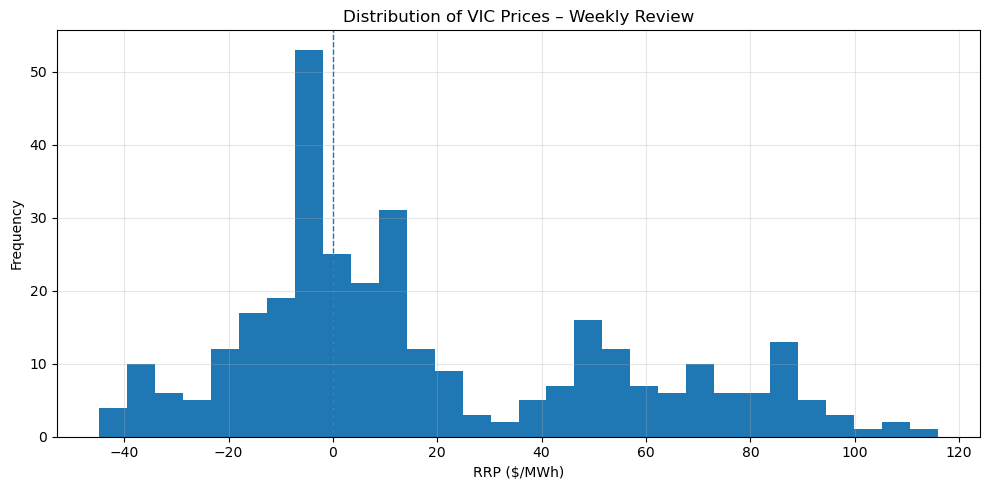

In [5]:
# --- Weekly price distribution ---
plt.figure(figsize=(10, 5))
plt.hist(weekly_df["RRP"], bins=30)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("RRP ($/MWh)")
plt.ylabel("Frequency")
plt.title("Distribution of VIC Prices – Weekly Review")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

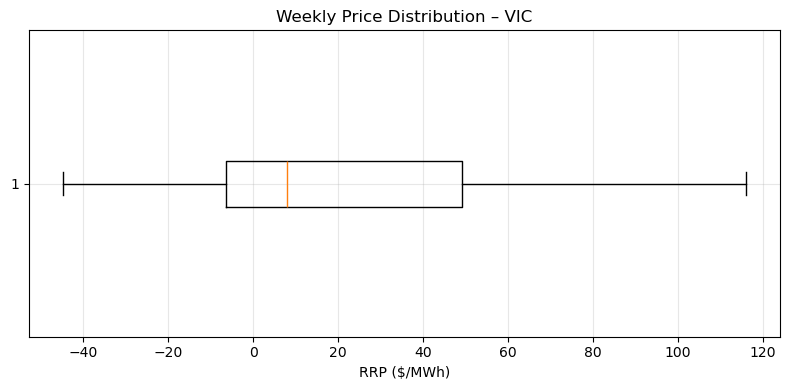

In [6]:
plt.figure(figsize=(8, 4))
plt.boxplot(weekly_df["RRP"], vert=False)
plt.xlabel("RRP ($/MWh)")
plt.title("Weekly Price Distribution – VIC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Daily spread analysis

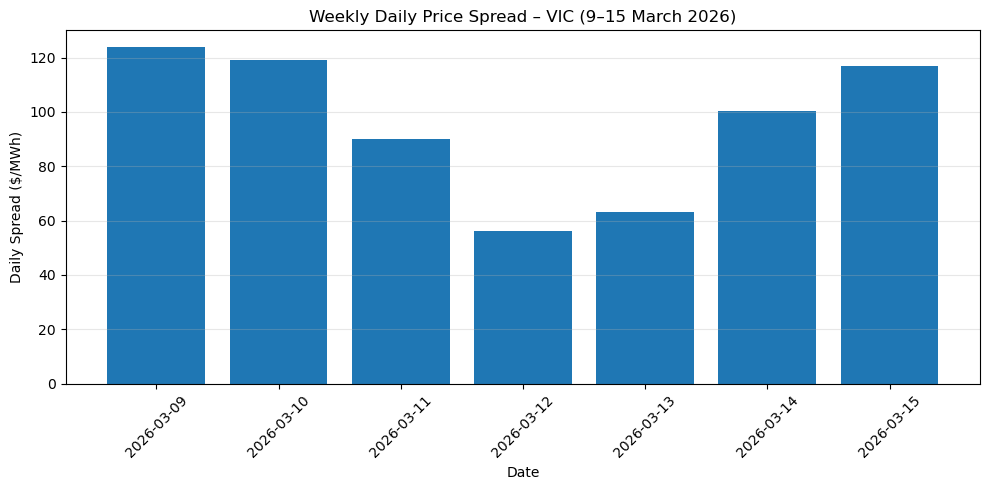

In [7]:
# --- Weekly daily spread chart ---
daily_spread = (
    weekly_df.groupby("DATE")["RRP"]
    .agg(["min", "max"])
    .reset_index()
)

daily_spread["spread"] = daily_spread["max"] - daily_spread["min"]

plt.figure(figsize=(10, 5))
plt.bar(daily_spread["DATE"].astype(str), daily_spread["spread"])
plt.xlabel("Date")
plt.ylabel("Daily Spread ($/MWh)")
plt.title("Weekly Daily Price Spread – VIC (9–15 March 2026)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
daily_spread = weekly_df.groupby("DATE")["RRP"].agg(["min", "max", "mean"]).reset_index()
daily_spread["spread"] = daily_spread["max"] - daily_spread["min"]

print(daily_spread.sort_values("spread", ascending=False))

         DATE        min         max       mean      spread
0  2026-03-09 -30.531170   93.286680  37.227227  123.817850
1  2026-03-10  -3.245000  115.946070  49.838129  119.191070
6  2026-03-15 -10.065615  106.890837  40.867419  116.956452
5  2026-03-14 -43.191667   57.083333   5.814191  100.275000
2  2026-03-11 -44.818333   45.295050  -2.184672   90.113383
4  2026-03-13 -39.258333   24.056448  -2.983437   63.314782
3  2026-03-12 -26.346667   29.777878   3.279316   56.124545


## Volatility check

In [9]:
daily_volatility = weekly_df.groupby("DATE")["RRP"].std().reset_index()
daily_volatility.columns = ["DATE", "RRP_STD"]

print(daily_volatility.sort_values("RRP_STD", ascending=False))

         DATE    RRP_STD
0  2026-03-09  44.335030
6  2026-03-15  39.752153
5  2026-03-14  33.472087
1  2026-03-10  32.768898
4  2026-03-13  17.664720
3  2026-03-12  14.680819
2  2026-03-11  14.629900


## Hourly pattern analysis

In [10]:
hourly_week = weekly_df.groupby("HOUR")[["RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]].mean()

print(hourly_week)

            RRP  TOTALDEMAND        PV_MW   NET_DEMAND
HOUR                                                  
0     30.633951  4762.500000     0.000000  4762.500000
1     28.167502  4499.714286     0.000000  4499.714286
2     26.191857  4322.000000     0.000000  4322.000000
3     28.406502  4261.000000     0.000000  4261.000000
4     33.692552  4325.071429     0.000000  4325.071429
5     37.255169  4578.857143     0.000000  4578.857143
6     39.346619  5051.214286    23.667571  5027.546714
7      7.562271  5206.642857   417.844786  4788.798071
8     -6.313550  4858.785714  1120.161143  3738.624571
9    -12.074272  4412.714286  1791.576429  2621.137857
10   -12.640134  4035.785714  2301.427286  1734.358429
11    -9.957979  3782.642857  2679.988571  1102.654286
12   -14.059013  3608.785714  2880.624214   728.161500
13   -13.014618  3636.714286  2811.126357   825.587929
14   -10.960208  3844.500000  2572.775929  1271.724071
15    -3.214858  4132.142857  2211.730571  1920.412286
16     8.9

## Plot the hourly pattern

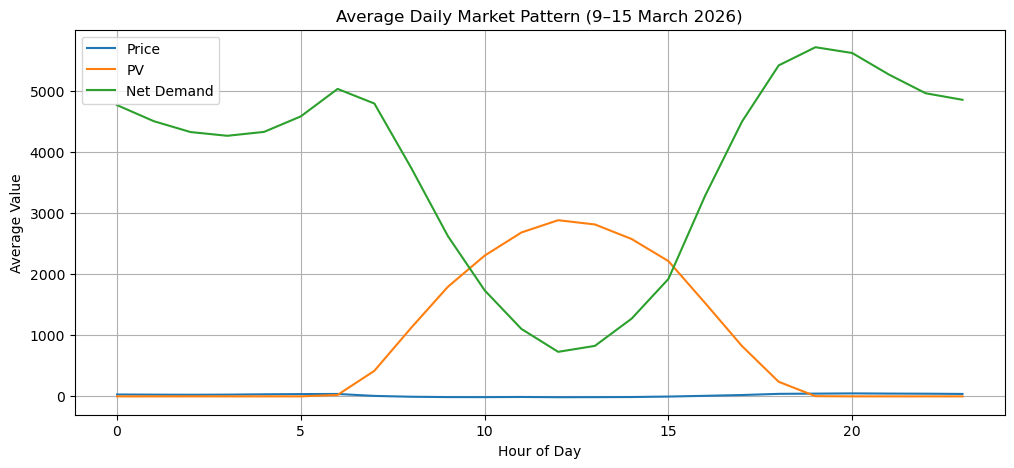

In [11]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 5)) 
plt.plot(hourly_week.index, hourly_week["RRP"], label="Price") 
plt.plot(hourly_week.index, hourly_week["PV_MW"], label="PV") 
plt.plot(hourly_week.index, hourly_week["NET_DEMAND"], label="Net Demand") 
plt.xlabel("Hour of Day")
plt.ylabel("Average Value") 
plt.title("Average Daily Market Pattern (9–15 March 2026)") 
plt.legend() 
plt.grid(True) 
plt.show()

## Correlation analysis


In [12]:
print(weekly_df[["RRP", "PV_MW", "TOTALDEMAND", "NET_DEMAND"]].corr())

                  RRP     PV_MW  TOTALDEMAND  NET_DEMAND
RRP          1.000000 -0.522281     0.378583    0.504566
PV_MW       -0.522281  1.000000    -0.665686   -0.938756
TOTALDEMAND  0.378583 -0.665686     1.000000    0.882056
NET_DEMAND   0.504566 -0.938756     0.882056    1.000000


In [13]:
## Identify strongest charging windows

In [14]:
neg_by_hour = neg_prices.groupby("HOUR").size()
print(neg_by_hour)

HOUR
0      2
1      3
2      4
3      4
4      2
5      2
6      2
7      9
8     12
9     13
10    14
11    12
12    11
13    12
14    11
15    10
16    10
17     5
18     3
dtype: int64


## Identify strongest discharge windows

In [15]:
high_prices = weekly_df.sort_values("RRP", ascending=False).head(20)
print(high_prices[["SETTLEMENTDATE", "RRP", "TOTALDEMAND", "PV_MW", "NET_DEMAND"]])

          SETTLEMENTDATE         RRP  TOTALDEMAND    PV_MW  NET_DEMAND
60   2026-03-10 06:00:00  115.946070         5198    0.000    5198.000
61   2026-03-10 06:30:00  107.351280         5570   36.743    5533.257
322  2026-03-15 20:30:00  106.890837         5335    0.000    5335.000
321  2026-03-15 20:00:00  102.956303         5500    0.000    5500.000
59   2026-03-10 05:30:00   98.991522         4882    0.000    4882.000
320  2026-03-15 19:30:00   98.156298         5693    0.000    5693.000
323  2026-03-15 21:00:00   98.030000         5146    0.000    5146.000
319  2026-03-15 19:00:00   94.100475         5735    0.929    5734.071
47   2026-03-09 23:30:00   93.286680         4810    0.000    4810.000
46   2026-03-09 23:00:00   92.012368         4734    0.000    4734.000
324  2026-03-15 21:30:00   89.579688         4975    0.000    4975.000
318  2026-03-15 18:30:00   89.509222         5787   64.742    5722.258
45   2026-03-09 22:30:00   89.103538         4813    0.000    4813.000
317  2

In [16]:
pivot_price = weekly_df.pivot_table(
    values="RRP",
    index="DATE",
    columns="HOUR",
    aggfunc="mean"
)

pivot_price

HOUR,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DATE,,,,,,,,,,,,,,,,,,,,,
2026-03-09,61.436127,66.717079,62.516018,69.436000,71.951282,73.760078,64.538092,13.338284,-17.541957,-12.630000,...,-0.909911,-1.275562,-1.281590,7.934955,81.123040,86.370534,86.382195,78.874533,88.303349,92.649524
2026-03-10,82.904136,73.630597,70.615329,72.908987,84.001382,93.730036,111.648675,40.754282,11.053160,-0.259070,...,38.420992,55.810911,64.421263,NaN,NaN,NaN,64.522221,56.397025,51.551326,21.938606
2026-03-11,6.549294,0.638460,-3.774233,-6.095428,-6.835606,-5.551419,-1.701941,-4.574359,-6.264086,-4.188187,...,-27.686061,-37.761667,-19.874986,-8.716664,-2.387194,11.040168,10.181029,10.792674,11.294592,14.709188
2026-03-12,9.010413,8.434901,9.896671,12.011993,21.317540,21.813057,24.913146,11.523067,-5.738333,-5.066667,...,-16.225000,-17.095833,-4.839167,-4.481802,6.199195,9.516283,12.292829,19.142264,13.821044,15.723447
2026-03-13,6.787508,0.796672,1.114179,4.946676,11.464369,16.225769,22.946115,-1.607227,-13.791612,-26.723884,...,-33.999167,-24.738350,-4.929167,13.805832,15.265047,10.122436,6.553333,8.432581,7.645022,6.765842
2026-03-14,-0.212898,-3.622485,-4.187092,-1.957861,8.835007,12.202005,9.668338,-3.741279,-6.381113,-27.093328,...,-29.154013,-17.342194,-3.690429,39.315336,56.830613,55.704036,55.515903,50.363301,49.512822,51.612242
2026-03-15,47.963077,50.577290,47.162128,47.595150,45.113889,48.606658,43.413906,-2.756872,-5.530907,-8.558766,...,-7.168299,19.898692,60.425762,84.156656,89.093772,96.128387,104.923570,93.804844,83.540666,74.722481


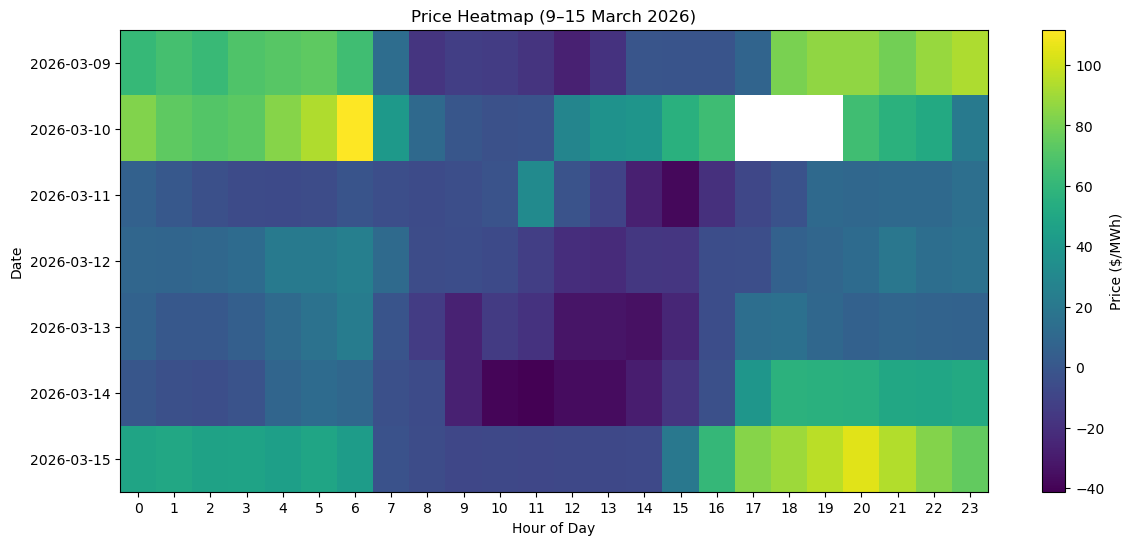

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.imshow(pivot_price, aspect="auto")

plt.colorbar(label="Price ($/MWh)")
plt.xticks(range(24), pivot_price.columns)
plt.yticks(range(len(pivot_price.index)), pivot_price.index)

plt.xlabel("Hour of Day")
plt.ylabel("Date")
plt.title("Price Heatmap (9–15 March 2026)")

plt.show()

## Day-by-Day Market Behaviour and BESS Opportunities

### 9 March 2026
The day shows moderate prices overnight, followed by a clear decline during the morning. Midday prices turn negative, indicating solar-driven oversupply. In the evening, prices rise significantly, creating a strong discharge opportunity.  
**BESS Insight:** Good arbitrage day — charge midday, discharge evening.

---

### 10 March 2026
Prices are relatively strong in the early morning, with a spike around early hours. Midday prices are lower but not deeply negative, and evening prices remain moderate.  
**BESS Insight:** Partial arbitrage opportunity — weaker than other days, selective cycling preferred.

---

### 11 March 2026
Prices remain relatively flat throughout the day, with only mild variation. There is limited evidence of strong midday suppression or evening peaks.  
**BESS Insight:** Weak arbitrage conditions — better to hold SOC or consider FCAS rather than aggressive cycling.

---

### 12 March 2026
The day shows a gradual decline in prices during midday, with moderate recovery in the evening. However, price spreads are not very strong.  
**BESS Insight:** Limited opportunity — partial cycling possible but not highly attractive.

---

### 13 March 2026
Clear solar impact is observed, with prices dropping significantly during midday and turning negative. Evening prices recover moderately.  
**BESS Insight:** Good charging opportunity midday; moderate discharge opportunity in evening.

---

### 14 March 2026
This is one of the strongest days for BESS trading. Deep negative prices are observed during midday, followed by a clear evening recovery.  
**BESS Insight:** Excellent arbitrage opportunity — strong charge-discharge cycle possible.

---

### 15 March 2026
Prices are stable overnight, slightly negative or low during midday, and very strong during the evening peak.  
**BESS Insight:** Strong discharge-focused day — good opportunity to monetise stored energy during evening peak.

---

## Weekly Summary Insight

Across the week, a consistent pattern emerges:
- Midday periods (10:00–14:00) provide the best charging opportunities due to solar-driven oversupply  
- Evening periods (17:00–21:00) provide the strongest discharge opportunities  
- Not all days offer strong arbitrage, highlighting the importance of selective BESS operation  

Overall, the week favours a strategy of charging during solar-driven weakness and discharging during evening peaks, with flexibility to adapt based on daily spread conditions.

## Competitor Behaviour Analysis

Based on observed market conditions, battery storage assets across the NEM likely exhibited consistent behavioural patterns during the week.

During periods of negative or low prices, particularly around midday, batteries are expected to have charged aggressively to absorb excess generation driven by high rooftop PV output.

During evening peak periods, when prices increased due to declining solar generation and rising demand, batteries likely discharged to capture higher prices.

However, differences in behaviour may have been observed:

- Some batteries may have charged aggressively during deep negative price events, particularly on 14 March, capturing strong arbitrage opportunities  
- Others may have preserved state of charge to target more valuable evening peaks  
- In weaker spread conditions, some batteries may have prioritised FCAS markets rather than energy arbitrage  
- Some assets may have missed optimal opportunities by charging too early or discharging too late  

These behavioural differences suggest varying trading strategies, risk preferences, and optimisation approaches among market participants.

## Key Weekly BESS Insights

### 1. Solar-driven price suppression creates reliable charging windows
Across the week, rooftop PV generation consistently reduced midday prices, often leading to low or negative price conditions. This creates predictable charging opportunities for battery storage systems.

### 2. Evening peaks provide the strongest discharge value
Evening periods consistently show higher prices due to reduced solar generation and increased demand. These periods represent the most reliable discharge windows for maximising revenue.

### 3. Arbitrage opportunities vary significantly by day
Not all days exhibit strong price spreads. Some days, such as 14 March, provide excellent arbitrage conditions, while others show flatter price profiles. This highlights the importance of selective operation rather than constant cycling.

---

## Trader Takeaways

- Avoid early charging and wait for solar-driven price weakness  
- Prioritise evening discharge windows for higher returns  
- Use selective cycling rather than full-cycle strategies in weaker markets  
- Maintain flexibility to respond to changing daily conditions  

## Final Summary

The week demonstrates a clear solar-driven market structure, where midday charging and evening discharging form the core BESS trading strategy. However, variability in daily price spreads highlights the importance of flexible and selective operation to maximise value.

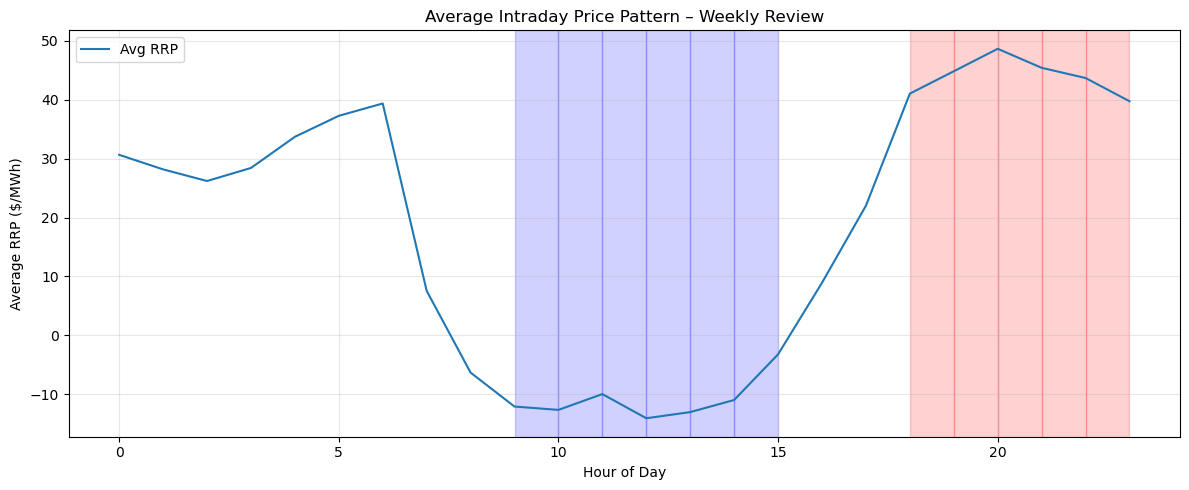

<Figure size 640x480 with 0 Axes>

In [18]:
weekly_intraday = (
    weekly_df.groupby("HOUR")[["RRP", "PV_MW", "NET_DEMAND"]]
    .mean()
    .reset_index()
)

charge_threshold_week = weekly_intraday["RRP"].quantile(0.25)
discharge_threshold_week = weekly_intraday["RRP"].quantile(0.75)

weekly_intraday["CHARGE_FLAG"] = weekly_intraday["RRP"] <= charge_threshold_week
weekly_intraday["DISCHARGE_FLAG"] = weekly_intraday["RRP"] >= discharge_threshold_week

plt.figure(figsize=(12, 5))
plt.plot(weekly_intraday["HOUR"], weekly_intraday["RRP"], label="Avg RRP")

for i in range(len(weekly_intraday) - 1):
    if weekly_intraday.iloc[i]["CHARGE_FLAG"]:
        plt.axvspan(
            weekly_intraday.iloc[i]["HOUR"],
            weekly_intraday.iloc[i + 1]["HOUR"],
            color="blue",
            alpha=0.18
        )

for i in range(len(weekly_intraday) - 1):
    if weekly_intraday.iloc[i]["DISCHARGE_FLAG"]:
        plt.axvspan(
            weekly_intraday.iloc[i]["HOUR"],
            weekly_intraday.iloc[i + 1]["HOUR"],
            color="red",
            alpha=0.18
        )

plt.xlabel("Hour of Day")
plt.ylabel("Average RRP ($/MWh)")
plt.title("Average Intraday Price Pattern – Weekly Review")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("Average Intraday Price Pattern – Weekly Review.png", dpi=300, bbox_inches="tight")

## Trading Signal Strip Plot

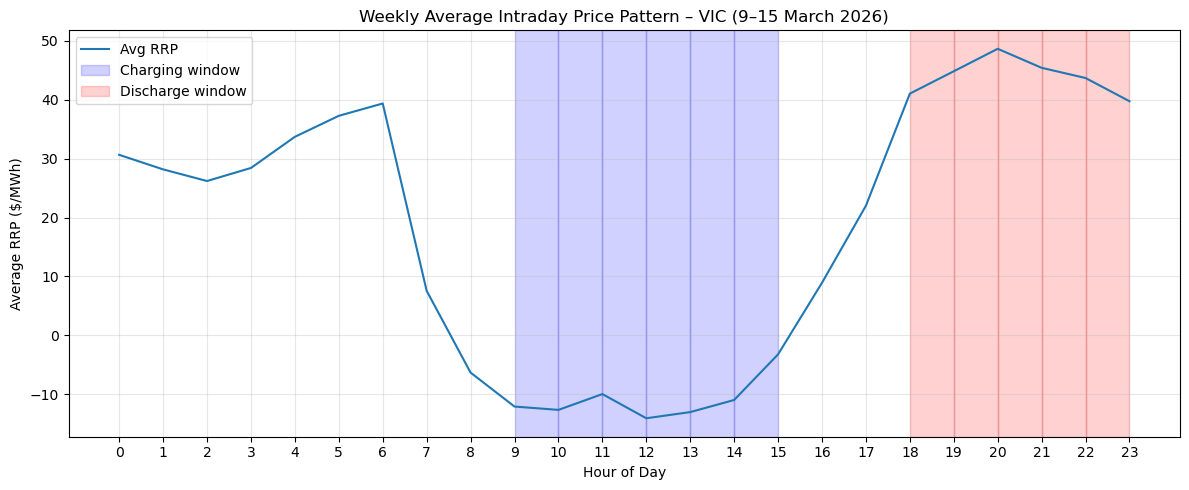

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- Create hourly average pattern ---
weekly_intraday = (
    weekly_df.groupby("HOUR")[["RRP", "PV_MW", "NET_DEMAND"]]
    .mean()
    .reset_index()
)

# --- Define thresholds ---
charge_threshold = weekly_intraday["RRP"].quantile(0.25)
discharge_threshold = weekly_intraday["RRP"].quantile(0.75)

weekly_intraday["CHARGE_FLAG"] = weekly_intraday["RRP"] <= charge_threshold
weekly_intraday["DISCHARGE_FLAG"] = weekly_intraday["RRP"] >= discharge_threshold

# --- Plot ---
plt.figure(figsize=(12, 5))

# Price line
plt.plot(weekly_intraday["HOUR"], weekly_intraday["RRP"], label="Avg RRP")

# Blue = charging windows
for i in range(len(weekly_intraday) - 1):
    if weekly_intraday.iloc[i]["CHARGE_FLAG"]:
        plt.axvspan(
            weekly_intraday.iloc[i]["HOUR"],
            weekly_intraday.iloc[i + 1]["HOUR"],
            color="blue",
            alpha=0.18
        )

# Red = discharge windows
for i in range(len(weekly_intraday) - 1):
    if weekly_intraday.iloc[i]["DISCHARGE_FLAG"]:
        plt.axvspan(
            weekly_intraday.iloc[i]["HOUR"],
            weekly_intraday.iloc[i + 1]["HOUR"],
            color="red",
            alpha=0.18
        )

# --- Custom legend ---
legend_elements = [
    Line2D([0], [0], label="Avg RRP"),
    Patch(facecolor="blue", edgecolor="blue", alpha=0.18, label="Charging window"),
    Patch(facecolor="red", edgecolor="red", alpha=0.18, label="Discharge window")
]

plt.legend(handles=legend_elements, loc="best")

plt.xlabel("Hour of Day")
plt.ylabel("Average RRP ($/MWh)")
plt.title("Weekly Average Intraday Price Pattern – VIC (9–15 March 2026)")
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("Weekly Average Intraday Price Pattern – VIC (9–15 March 2026).png", bbox_inches="tight")
plt.show()
